# 🎡 Baseline Fine-Tuning with ResNet50 (8 Classes)

## ✨ Introduction

This notebook presents a **strong and well-established baseline** for group activity recognition using deep learning. Instead of experimenting with unproven ideas, the focus here is on **reliable fine-tuning strategies** that are widely validated in the literature.

Following classical CVPR approaches that relied on **AlexNet**, we adopt a **more powerful backbone (ResNet50)** to benefit from deeper representations and improved generalization.

For each video clip, we initially use **only the middle frame** as a representative image. This simplifies the pipeline while preserving discriminative information. Optionally, temporal context can be incorporated by sampling **5 frames before and 4 frames after** the center frame.

The model is fine-tuned as an **8-class image classifier**, and evaluation metrics are reported to establish a **clean, reproducible first baseline**. This baseline will serve as a reference point for future improvements and more advanced temporal modeling.

> **Note:** The goal of this notebook is not to maximize performance, but to establish a trustworthy and reproducible baseline.


In [ ]:
!pip install -r /content/drive/MyDrive/Volleyball-Project/requirements.txt >/dev/null 2>&1

In [ ]:
import os
import sys
import types
import importlib

try:
  # Python 3: importlib.reload exists
  import importlib
  reload_func = importlib.reload

except ImportError:
  # Python 2 fallback: use built-in reload
  reload_func = reload

# Only create fake 'imp' if it doesn't exist
if "imp" not in sys.modules:
  imp = types.ModuleType("imp")
  imp.reload = reload_func
  sys.modules["imp"] = imp

# Now load autoreload
%load_ext autoreload
%autoreload 2

PROJECT_ROOT = r'/content/drive/MyDrive/Volleyball-Project'
DATASET_ROOT = r'/content/drive/MyDrive/Volleyball_dataset/volleyball_dataset'
if PROJECT_ROOT not in sys.path:
  sys.path.insert(0, PROJECT_ROOT)

if DATASET_ROOT not in sys.path:
  sys.path.insert(1, DATASET_ROOT)
sys.path[:2]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
!ls '/content/drive/MyDrive/Volleyball-Project'

 Configurations   Helper     requirements.txt
 Data_utils	  Modeling  'Volleyball Video-Annotation Analysis.ipynb'


In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
from Helper import helper_functions
from Modeling.Backbones import resnet50
from torch.utils.data import DataLoader
from Modeling.BaseLine1 import model, trainer, tester
from Data_utils.data_loader import Group_activity_Dataset
from Configurations.Baseline_b1_tuned import ModelConfig, TrainingConfig

import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)

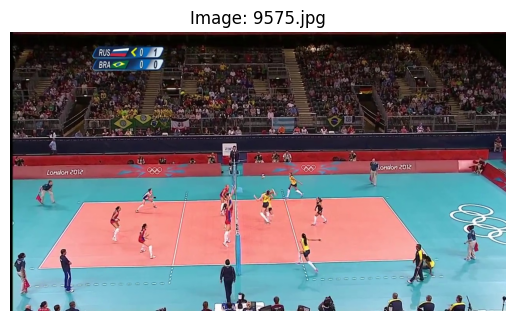

In [ ]:
img =Path(r'/content/drive/MyDrive/Volleyball_dataset/volleyball_dataset/videos/1/9575/9575.jpg')
if not img.exists():
    print(f"Error: File does not exist at {img}")
else:
    image = Image.open(img)
    image = ImageOps.exif_transpose(image)
    image = image.convert("RGB")
    plt.imshow(image)
    plt.title(f"Image: {img.name}")
    plt.axis('off')
    plt.show()

In [ ]:
model_config = ModelConfig()
train_config = TrainingConfig()

In [ ]:
import torchvision.transforms as T
# Perpare Data Augmentation
train_transform = T.Compose([
    T.Resize((256, 256)), # Resize shorter side to 256
    T.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    T.RandomRotation(degrees=3),
    T.ColorJitter(0.3, 0.3, 0.3, 0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((256, 256)),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Path to the videos directory inside the dataset
videos_root = os.path.join(DATASET_ROOT,'videos')

# Number of worker processes used for data loading
# > 0 enables parallel data loading
num_workers = min(4, os.cpu_count() or 1)

# Pin memory is only useful when training on CUDA
# It speeds up CPU → GPU memory transfers
pin_memory = model_config.device == "cuda"

loader_kwargs = dict(
  num_workers = num_workers,
  pin_memory = pin_memory,
  persistent_workers=num_workers > 0,
  # persistent_workers Keeps worker processes alive between epochs
  # Must be False when num_workers == 0
)

# prefetch_factor controls how many batches each worker preloads
# It is only valid when num_workers > 0
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2

# Training dataset (uses training split indices)
train_dataset = Group_activity_Dataset(videos_root, model_config.train_split, train_transform)
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=train_config.batch_size,
                          shuffle=True,
                          **loader_kwargs)

# Validation dataset (no data augmentation, no shuffling)
val_dataset = Group_activity_Dataset(videos_root, model_config.val_split, val_transform)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=train_config.val_bsize,
                        shuffle=False,
                        **loader_kwargs)

# Test dataset (used only for final evaluation)
test_dataset = Group_activity_Dataset(videos_root, model_config.test_split, val_transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=train_config.val_bsize,
                         shuffle=False,
                         **loader_kwargs)

In [ ]:
train_dataset.summary, val_dataset.summary, test_dataset.summary

({'Images_Count': 2152, 'Unique_Labels': 8},
 {'Images_Count': 1341, 'Unique_Labels': 8},
 {'Images_Count': 1337, 'Unique_Labels': 8})

In [ ]:
truncated_model = resnet50.ResNet50()

with torch.no_grad():
  dummy = torch.zeros(1, 3, 224, 224)
  num_last_features = truncated_model(dummy).shape[1]

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
BaseLine1_model = model.ExtendedModel_Baseline1(truncated_model, num_last_features, model_config.num_classes, model_config.dropout)
optimizer = torch.optim.AdamW(BaseLine1_model.parameters(), lr = train_config.learning_rate_backbone, betas=train_config.betas, weight_decay=train_config.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer = optimizer, T_max=train_config.epochs, eta_min=train_config.eta_min)

In [ ]:
helper_functions.model_summary(BaseLine1_model, model_config.device)

Layer (type:depth-idx)                             Output Shape              Param #
ExtendedModel_Baseline1                            [1, 8]                    --
├─ResNet50: 1-1                                    [1, 2048, 1, 1]           --
│    └─Sequential: 2-1                             [1, 2048, 1, 1]           --
│    │    └─Conv2d: 3-1                            [1, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                       [1, 64, 112, 112]         128
│    │    └─ReLU: 3-3                              [1, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                         [1, 64, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 256, 56, 56]          215,808
│    │    └─Sequential: 3-6                        [1, 512, 28, 28]          1,219,584
│    │    └─Sequential: 3-7                        [1, 1024, 14, 14]         7,098,368
│    │    └─Sequential: 3-8                        [1, 2048, 7, 7]           14,964,736
│   

In [ ]:
from Helper.helper_functions import set_all_seeds, accuracy_fn, save_checkpoints
from torch.cuda.amp import  GradScaler # PERFORMANCE OPTIMIZATIONS
scaler = GradScaler()  # helps scale gradients safely

set_all_seeds(42)
train_history, val_history = {}, {}
train_acc_values, val_acc_values = [], []
epoch_values, val_losses_values, train_losses_values, lr_history = [], [], [], []

best_loss = float('inf')
best_macro_f1 = 0.0
for epoch in tqdm(iterable=range(train_config.epochs), desc="Training Model[BaseLine1]...!"):
  # Train → Validate → Compute Macro F1 → Save if best → Scheduler step

  # ---- Train ----
  train_history = trainer.train_step(model= BaseLine1_model,
                                     dataloader= train_loader,
                                     accuracy_fn= accuracy_fn,
                                     criterion= criterion,
                                     optimizer= optimizer,
                                     scaler= scaler,
                                     device= model_config.device)

  # ---- Validate ----
  val_history = trainer.eval_step(model= BaseLine1_model,
                                  dataloader= val_loader,
                                  accuracy_fn= accuracy_fn,
                                  criterion= criterion,
                                  device= model_config.device)

  # ---- Logging ----
  train_losses_values.append(train_history['Train_loss'])
  train_acc_values.append(train_history['Train_acc'])

  val_losses_values.append(val_history['Test_loss'])
  val_acc_values.append(val_history['Test_acc'])

  lr_history.append(optimizer.param_groups[0]['lr'])
  epoch_values.append(epoch)

  # ---- Checkpoint ----
  if val_history['Macro_f1'] > best_macro_f1:
    best_macro_f1 = val_history['Macro_f1']
    save_checkpoints(BaseLine1_model, scaler, optimizer, train_history['Train_loss'], val_history['Test_loss'], best_macro_f1, epoch+1, os.path.join(train_config.checkpoint_path, f"checkpoint_epoch{epoch+1}.pt"))

  # ---------- SCHEDULER ----------
  scheduler.step() # CosineAnnealingLR check per epoch or batch,  ALWAYS after validation

  # ---- Print ----
  if(epoch+1) % train_config.print_every == 0:
    print(f"Epoch [{epoch+1:>2}] - Macro F1: {val_history['Macro_f1']:.3f} | Train loss: {train_history['Train_loss']:.3f} | Train acc: {train_history['Train_acc']:.3f}% | Test loss: {val_history['Test_loss']:.3f} | Test acc: {val_history['Test_acc']:.3f}% | LR: {scheduler.get_last_lr()[0]:.6f}")

Training Model[BaseLine1]...!:   0%|          | 0/50 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/Volleyball-Project/Modeling/BaseLine1/chekpoints/checkpoint_epoch1.pt
Epoch [ 1] - Macro F1: 0.312 | Train loss: 1.972 | Train acc: 22.151% | Test loss: 1.787 | Test acc: 36.797% | LR: 0.000300
Saved checkpoint: /content/drive/MyDrive/Volleyball-Project/Modeling/BaseLine1/chekpoints/checkpoint_epoch2.pt
Epoch [ 2] - Macro F1: 0.481 | Train loss: 1.533 | Train acc: 48.759% | Test loss: 1.518 | Test acc: 51.670% | LR: 0.000299
Saved checkpoint: /content/drive/MyDrive/Volleyball-Project/Modeling/BaseLine1/chekpoints/checkpoint_epoch3.pt
Epoch [ 3] - Macro F1: 0.662 | Train loss: 1.328 | Train acc: 58.961% | Test loss: 1.235 | Test acc: 65.438% | LR: 0.000297
Saved checkpoint: /content/drive/MyDrive/Volleyball-Project/Modeling/BaseLine1/chekpoints/checkpoint_epoch4.pt
Epoch [ 4] - Macro F1: 0.688 | Train loss: 1.192 | Train acc: 65.303% | Test loss: 1.220 | Test acc: 68.637% | LR: 0.000295
Saved checkpoint: /content/drive/MyDrive/Volleyball-Project/

In [ ]:
model = model.ExtendedModel_Baseline1(
  backbone= truncated_model,
  num_features= num_last_features,
  num_classes= model_config.num_classes
)

res = helper_functions.load_checkpoint(path = r'/content/drive/MyDrive/Volleyball-Project/Modeling/BaseLine1/chekpoints/checkpoint_epoch47.pt',device= model_config.device)
model.load_state_dict(res['model_state_dict'])

<All keys matched successfully>

In [ ]:
Model_result = trainer.eval_step(model, test_loader, accuracy_fn, criterion, model_config.device)
Model_result

{'Model_name': 'ExtendedModel_Baseline1',
 'Test_loss': 0.9261312640848613,
 'Test_acc': 82.77083333333333,
 'Macro_f1': 0.8428178695587132}

In [ ]:
y_true, y_preds = tester.test_step(model, test_loader, model_config.device)

Making predictions:   0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
helper_functions.Display_Classification_Report(y_true, y_preds, model_config.classes_names)

Classification Report:
              precision    recall  f1-score   support

       r_set       0.72      0.77      0.74       192
     r_spike       0.92      0.80      0.86       173
      r-pass       0.75      0.79      0.77       210
  r_winpoint       0.92      0.92      0.92        87
  l_winpoint       0.92      0.95      0.94       102
      l-pass       0.81      0.80      0.80       226
     l-spike       0.94      0.89      0.91       179
       l_set       0.78      0.82      0.80       168

    accuracy                           0.83      1337
   macro avg       0.85      0.84      0.84      1337
weighted avg       0.83      0.83      0.83      1337



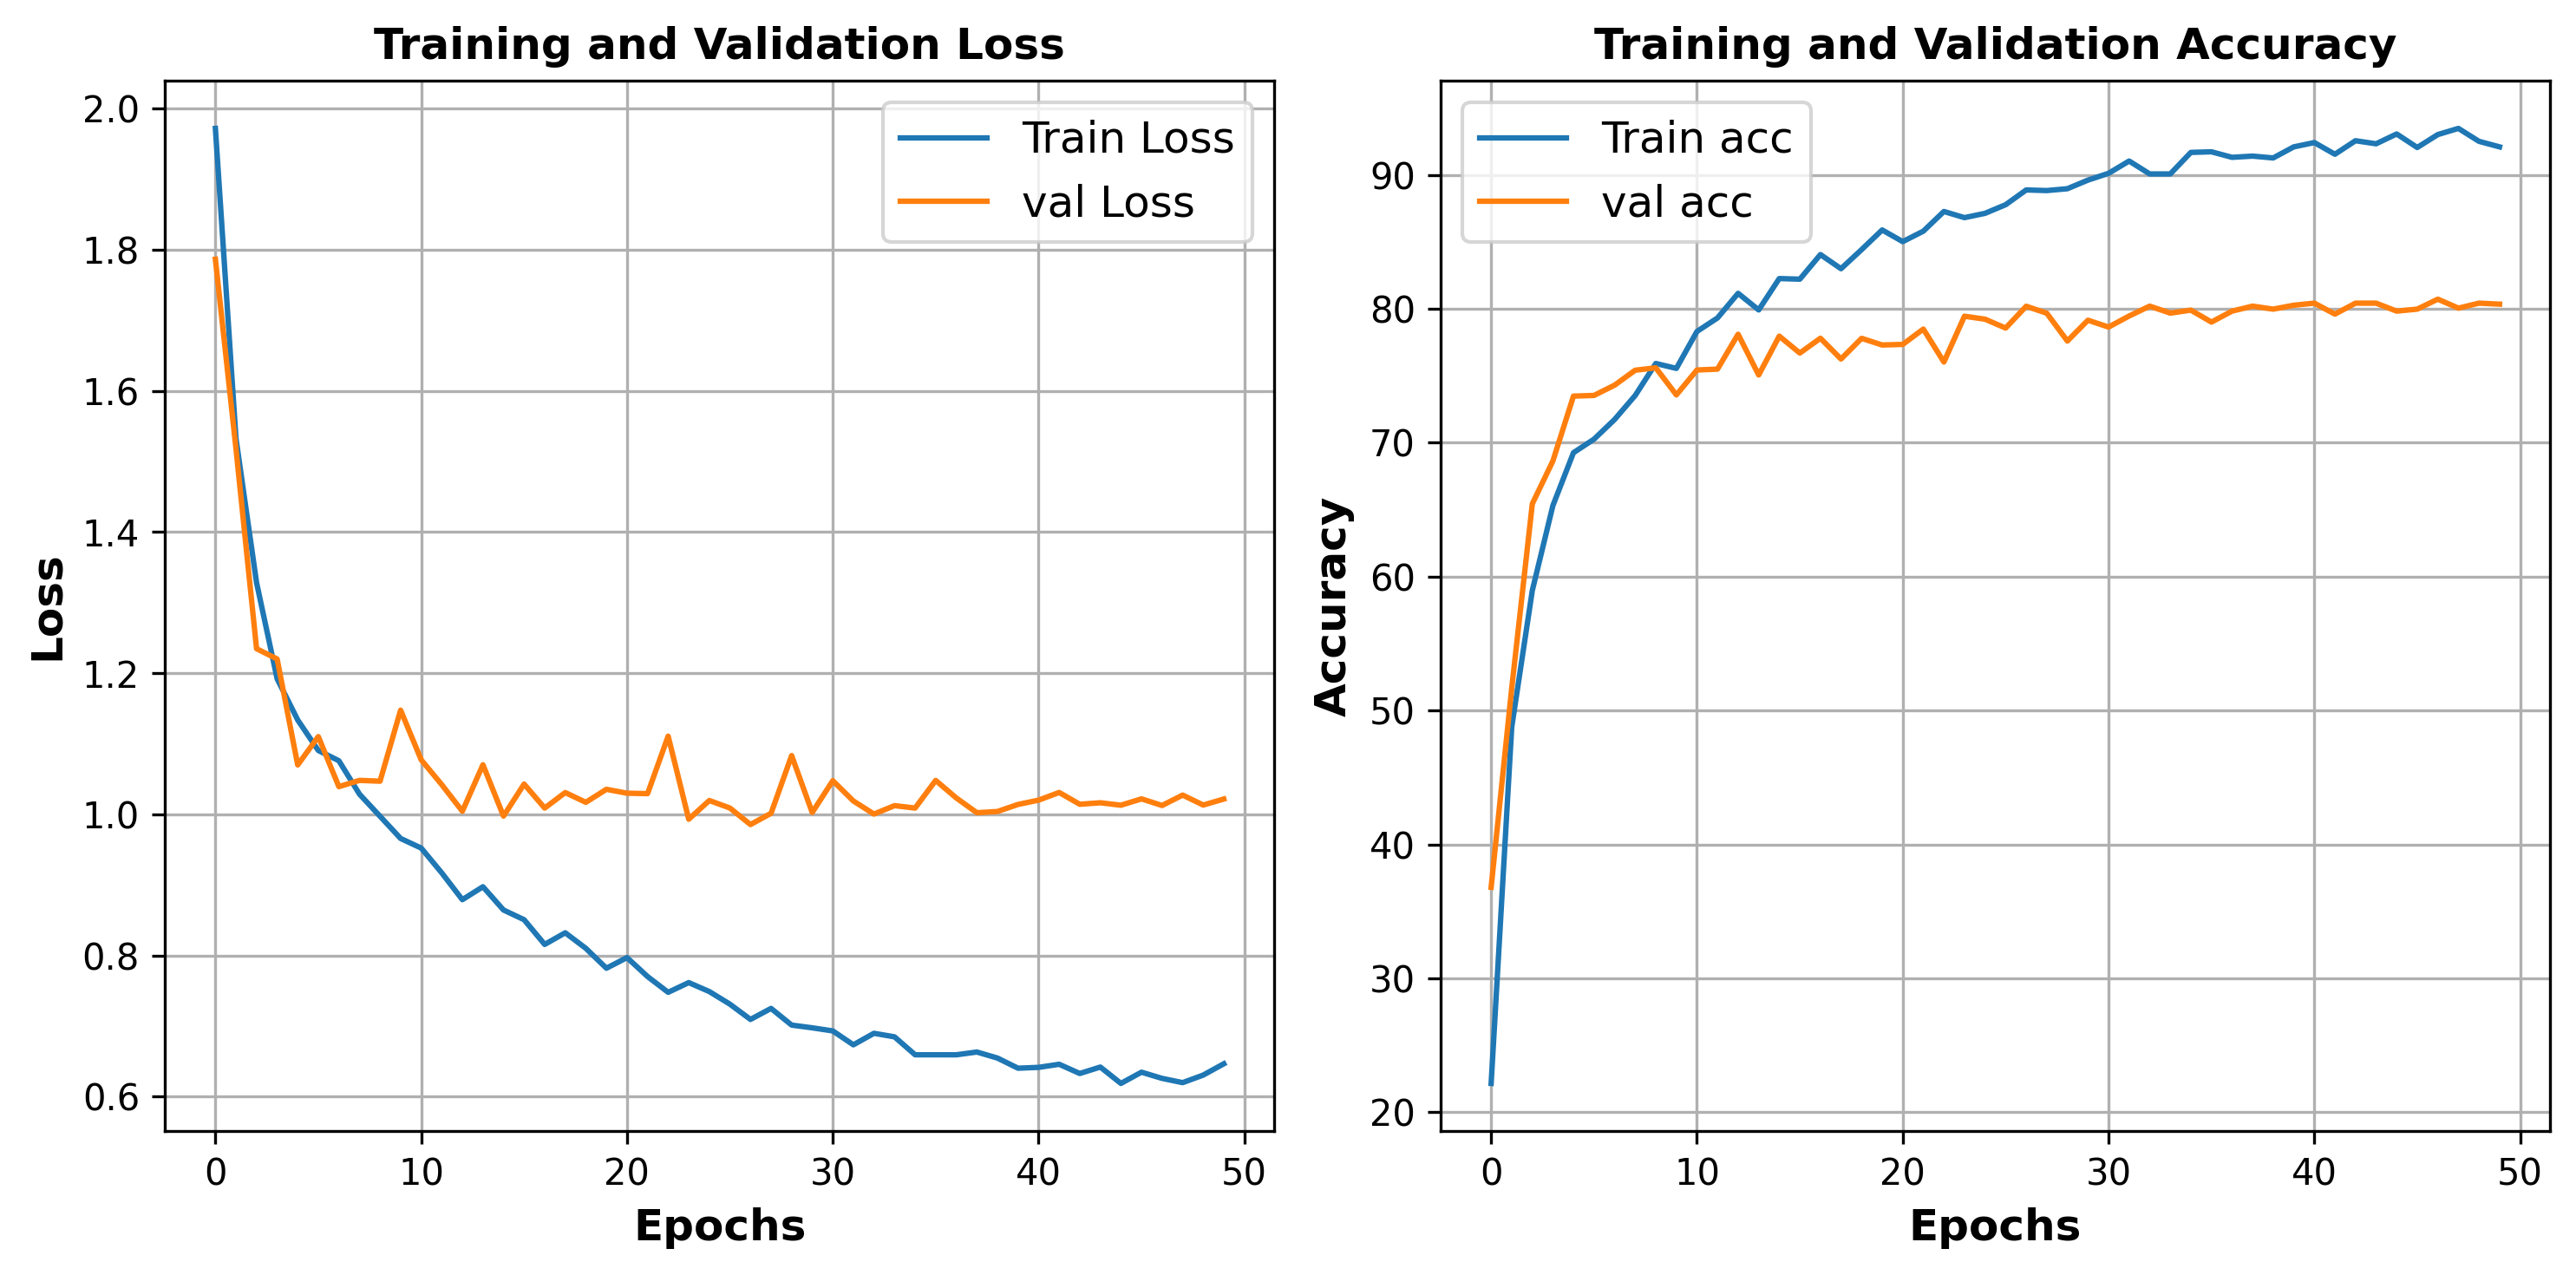

In [ ]:
helper_functions.Display_train_eval_curves(epoch_values, train_losses_values, val_losses_values, train_acc_values, val_acc_values)

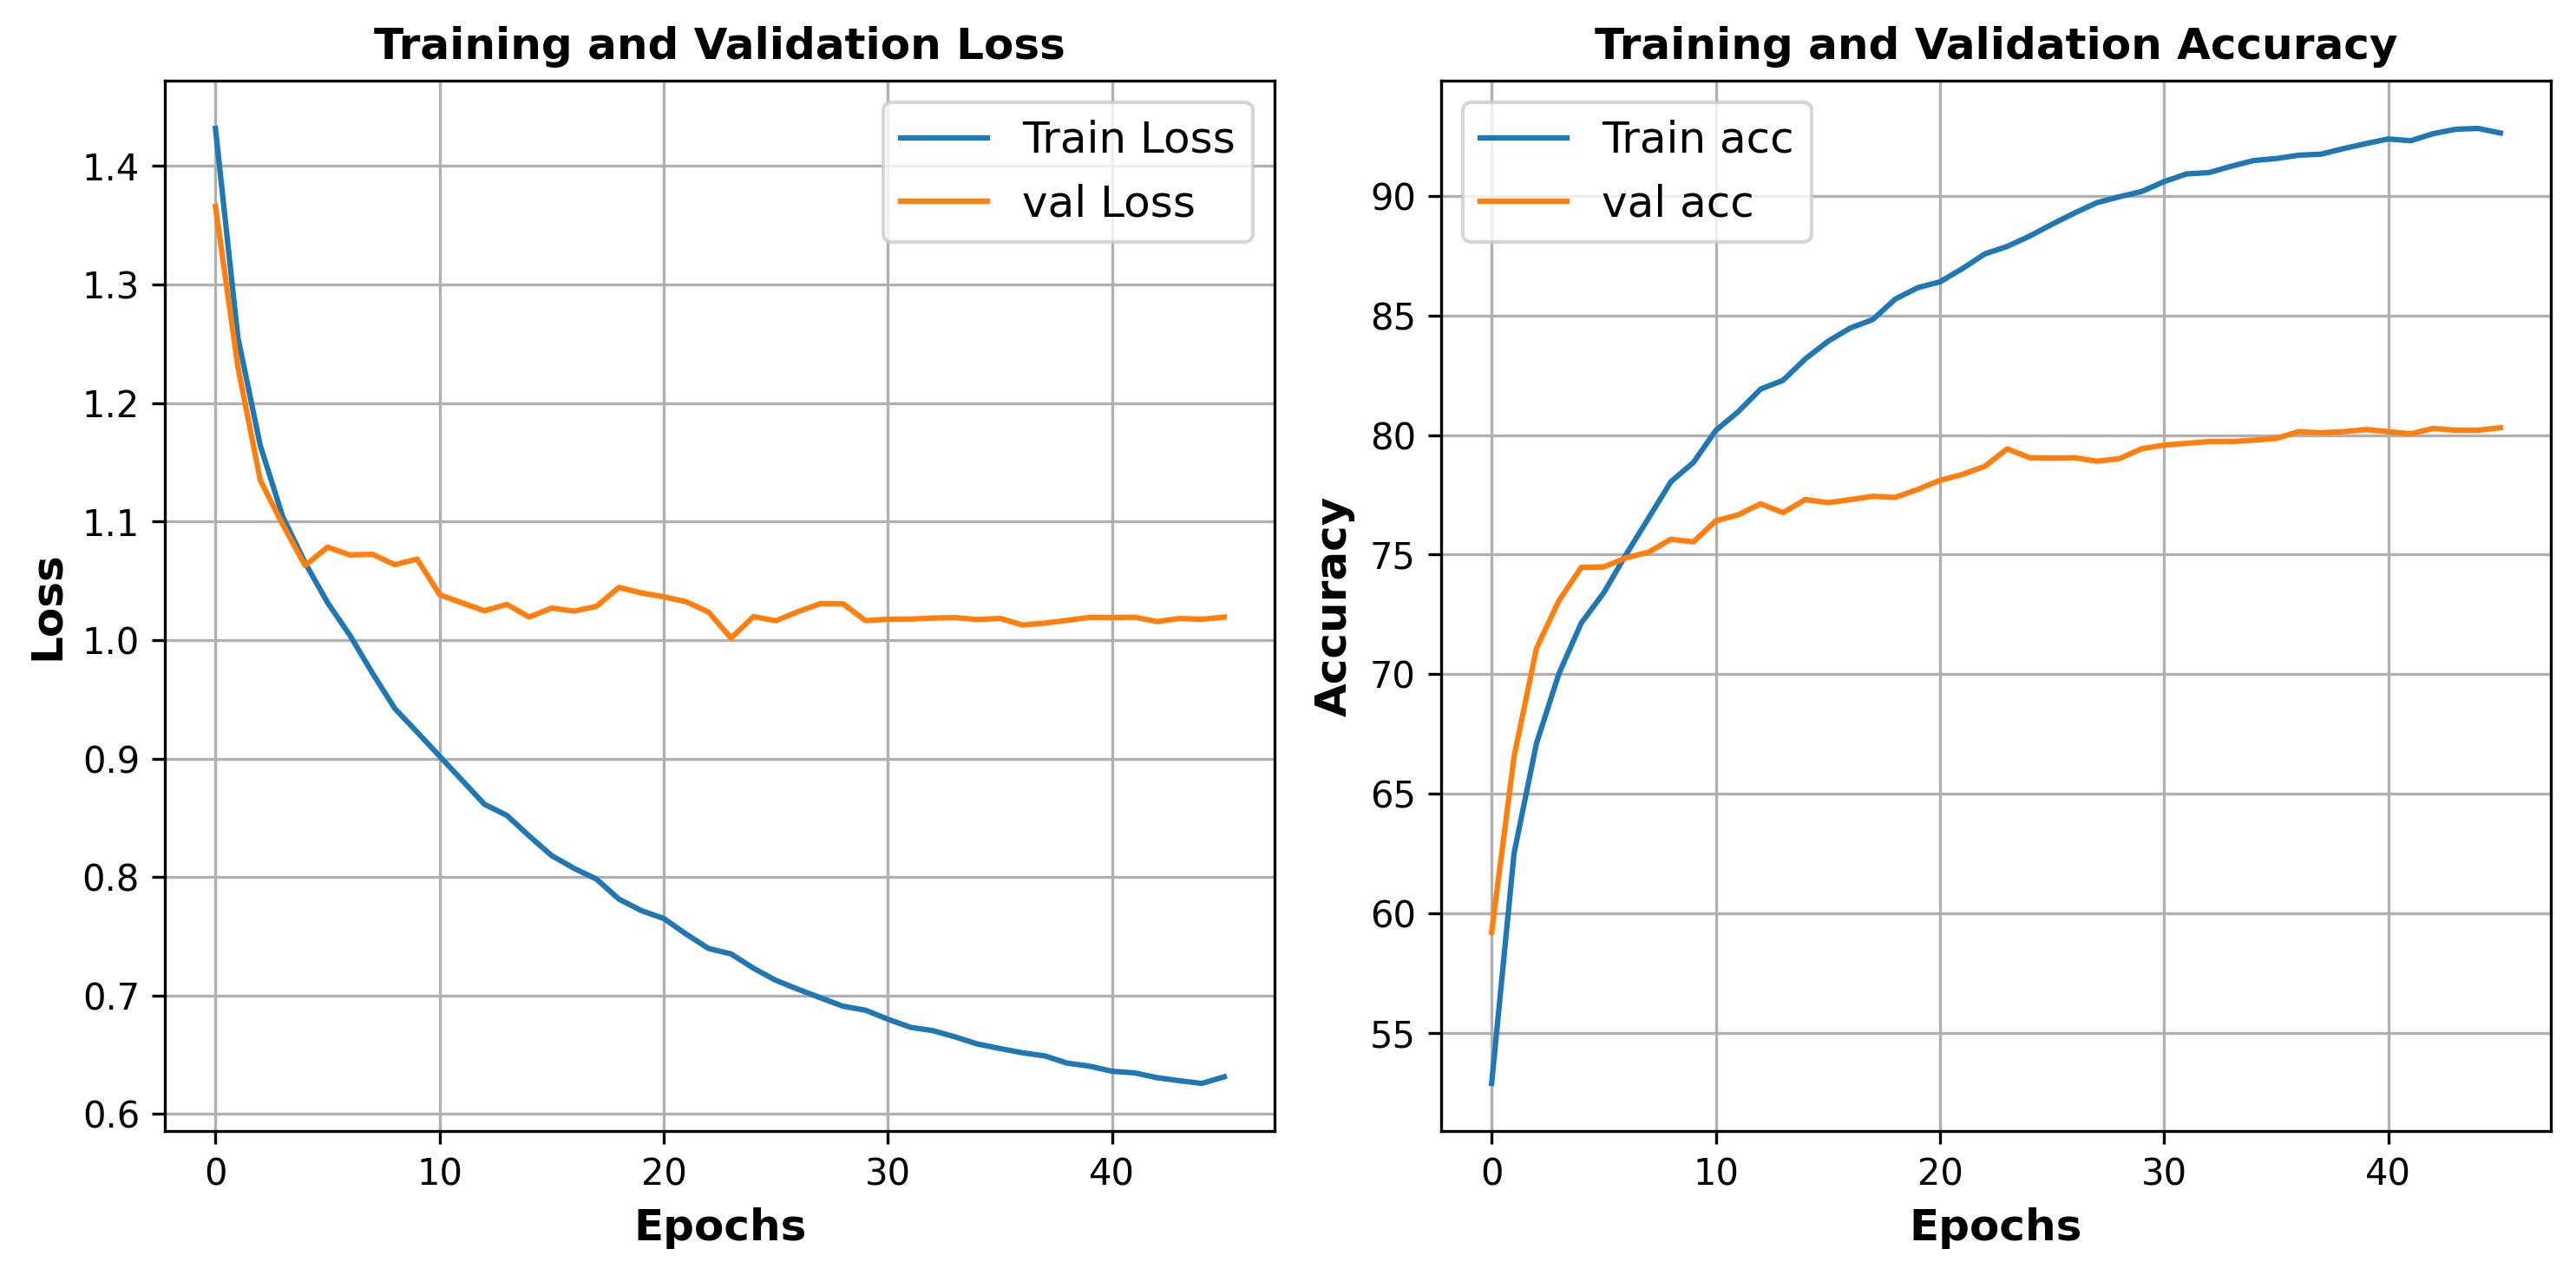

In [ ]:
helper_functions.Display_train_eval_smooth_curves(epoch_values, train_losses_values, val_losses_values, train_acc_values, val_acc_values)

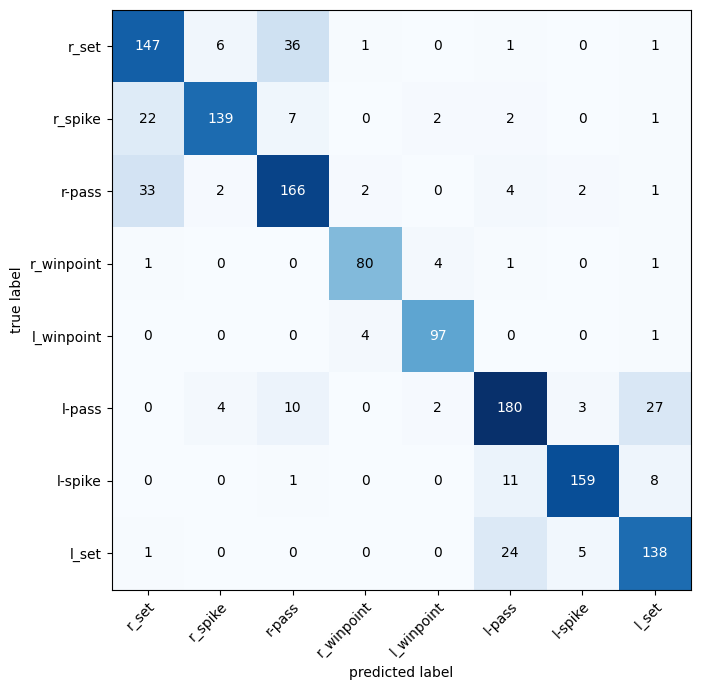

In [ ]:
helper_functions.Display_Confusion_matrix(y_true, y_preds, model_config.classes_names)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">END OF YOUR CODE</div>